In [20]:
import pandas as pd 
import numpy as np 
import warnings 
warnings.filterwarnings("ignore")

In [21]:
monthly_df = pd.read_csv("../data/monthly_data.csv",index_col="Datetime",parse_dates=True)

In [22]:
monthly_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-31,41813.282,2889.436,5309773.22,176594.8,27460.0,48712.0,162951.0
2007-01-31,69011.862,5922.396,10753521.91,292241.2,56433.0,79274.0,329578.0
2007-02-28,56488.886,4581.608,9697260.78,238463.6,47584.0,64604.0,270274.0
2007-03-31,58862.192,5122.184,10736280.75,248772.2,60769.0,104762.0,290361.0
2007-04-30,35181.466,4688.994,9450794.83,151026.2,42078.0,38417.0,189503.0


In [23]:
monthly_df.shape

(48, 7)

In [24]:
print(monthly_df.index.min())
print(monthly_df.index.max())

2006-12-31 00:00:00
2010-11-30 00:00:00


In [25]:
monthly_df.columns

Index(['Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

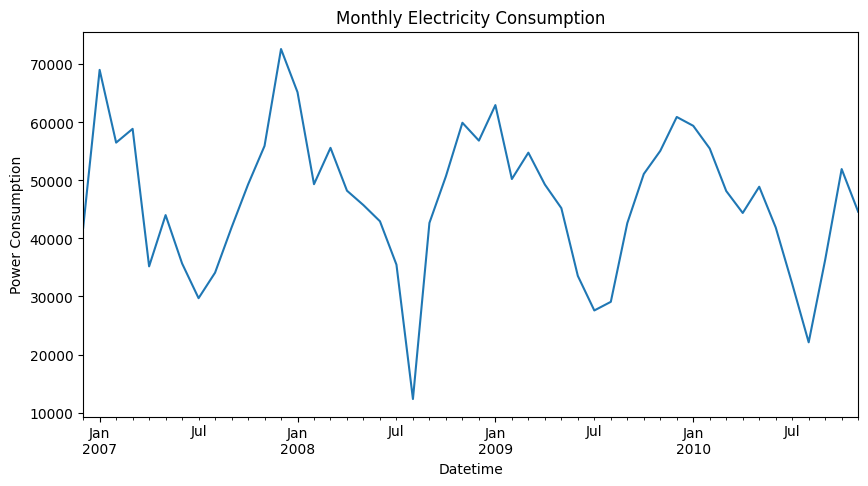

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
monthly_df['Global_active_power'].plot()
plt.title("Monthly Electricity Consumption")
plt.ylabel("Power Consumption")
plt.show()

creating lag features because the dataset it timeseries and seasonal based

In [27]:
monthly_df['lag_1'] = monthly_df['Global_active_power'].shift(1)
monthly_df['lag_2'] = monthly_df['Global_active_power'].shift(2)
monthly_df['lag_3'] = monthly_df['Global_active_power'].shift(3)
monthly_df['lag_12'] = monthly_df['Global_active_power'].shift(12)

In [28]:
monthly_df = monthly_df.dropna()

In [29]:
monthly_df.shape

(36, 11)

In [30]:
X = monthly_df[['lag_1', 'lag_2', 'lag_3', 'lag_12']]
y = monthly_df['Global_active_power']

In [31]:
train_size = int(len(monthly_df) * 0.8)

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

X_test = X.iloc[train_size:]
y_test = y.iloc[train_size:]

In [32]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
y_pred = lr.predict(X_test)

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 4971.811397523541
RMSE: 6649.312545944878


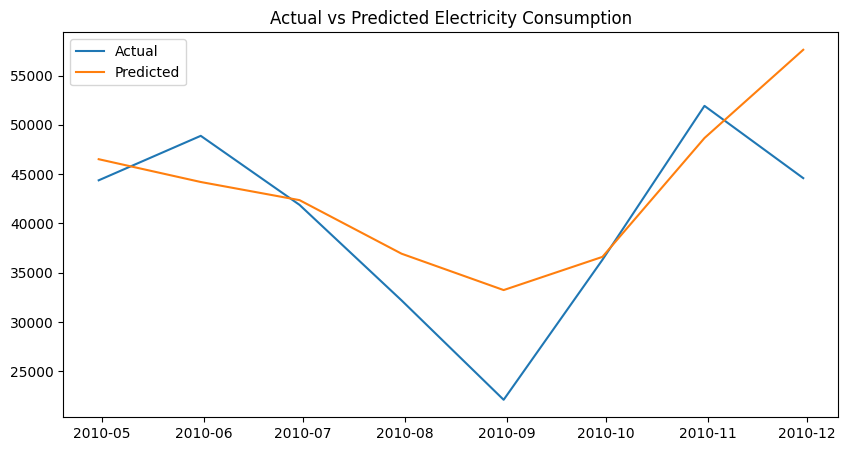

In [22]:
plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Electricity Consumption")
plt.show()

In [23]:
print("Mean monthly consumption:", y.mean())

Mean monthly consumption: 46808.54344444445


now we will be focusing more on seasonal effects when it comes to monthly analysis

In [24]:
monthly_df['month'] = monthly_df.index.month

In [25]:
monthly_df['month']

Datetime
2007-12-31    12
2008-01-31     1
2008-02-29     2
2008-03-31     3
2008-04-30     4
2008-05-31     5
2008-06-30     6
2008-07-31     7
2008-08-31     8
2008-09-30     9
2008-10-31    10
2008-11-30    11
2008-12-31    12
2009-01-31     1
2009-02-28     2
2009-03-31     3
2009-04-30     4
2009-05-31     5
2009-06-30     6
2009-07-31     7
2009-08-31     8
2009-09-30     9
2009-10-31    10
2009-11-30    11
2009-12-31    12
2010-01-31     1
2010-02-28     2
2010-03-31     3
2010-04-30     4
2010-05-31     5
2010-06-30     6
2010-07-31     7
2010-08-31     8
2010-09-30     9
2010-10-31    10
2010-11-30    11
Name: month, dtype: int32

In [26]:
X = monthly_df[['lag_1', 'lag_2', 'lag_3', 'lag_12', 'month']]

In [27]:
train_size = int(len(monthly_df) * 0.8)

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

X_test = X.iloc[train_size:]
y_test = y.iloc[train_size:]

In [28]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
y_pred = lr.predict(X_test)

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 4987.213122229758
RMSE: 6720.118510115213


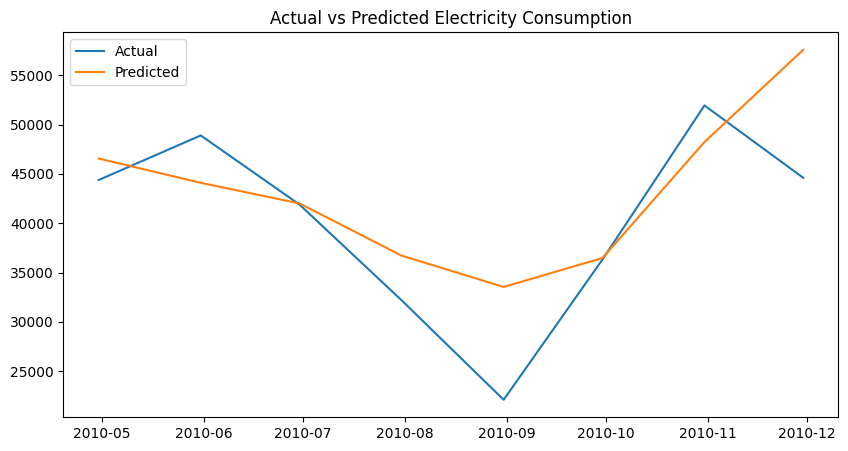

In [31]:
plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Electricity Consumption")
plt.show()

In [32]:
import numpy as np 

monthly_df['month_sin'] = np.sin(2 * np.pi * monthly_df.index.month / 12)
monthly_df['month_cos'] = np.cos(2 * np.pi * monthly_df.index.month / 12)


X = monthly_df[['lag_1', 'lag_2', 'lag_3', 'lag_12', 'month_sin','month_cos']]

In [33]:
train_size = int(len(monthly_df) * 0.8)

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

X_test = X.iloc[train_size:]
y_test = y.iloc[train_size:]

In [35]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
y_pred = lr.predict(X_test)

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 5437.58706883131
RMSE: 6982.5718120724405


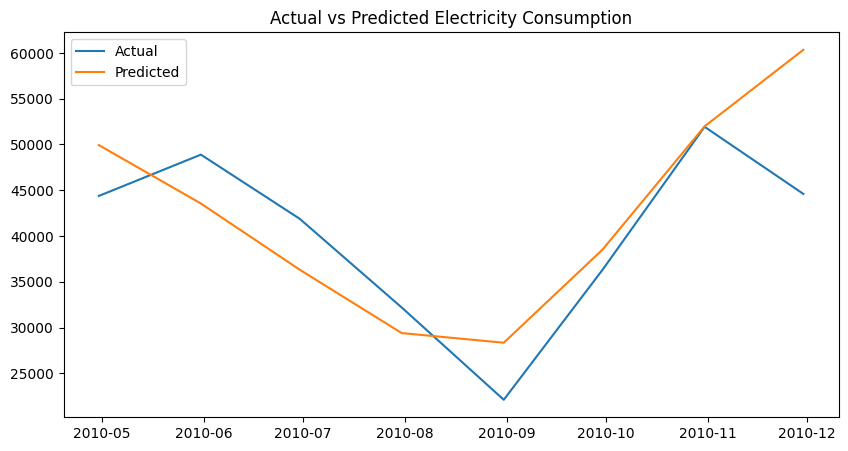

In [38]:
plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Electricity Consumption")
plt.show()

our final model for monthlydf after experimenting is 

In [39]:
X = monthly_df[['lag_1', 'lag_2', 'lag_3', 'lag_12']]

In [40]:
train_size = int(len(monthly_df) * 0.8)

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

X_test = X.iloc[train_size:]
y_test = y.iloc[train_size:]

In [43]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=200,random_state=42)

model_rf.fit(X_train,y_train)
y_pred_rf = model_rf.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("RF MAE:", mae_rf)
print("RF RMSE:", rmse_rf)

RF MAE: 5615.07267750001
RF RMSE: 6213.558766962739


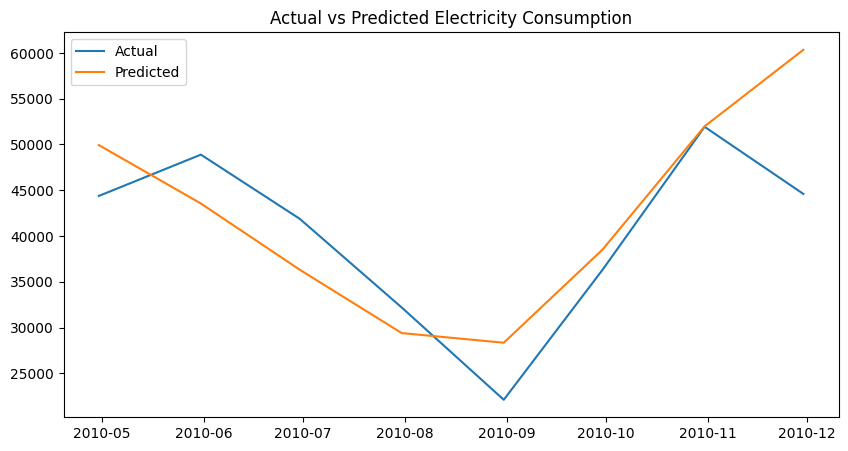

In [44]:
plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Electricity Consumption")
plt.show()

In [45]:
def prepare_lag_dataset(monthly_df):
    """
    Prepares lag feature dataset for time series forecasting.
    """

    X = monthly_df[['lag_1', 'lag_2', 'lag_3', 'lag_12']]
    y = monthly_df['Global_active_power']

    train_size = int(len(monthly_df) * 0.8)

    X_train = X.iloc[:train_size]
    y_train = y.iloc[:train_size]

    X_test = X.iloc[train_size:]
    y_test = y.iloc[train_size:]

    return X_train, X_test, y_train, y_test

LogisticRegression

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def run_linear_regression(X_train, X_test, y_train, y_test):

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return model, mae, rmse, y_pred

RandomForestRegressor

In [47]:
from sklearn.ensemble import RandomForestRegressor

def run_random_forest(X_train, X_test, y_train, y_test):

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return model, mae, rmse, y_pred

XGBoost ensemble

In [48]:
from xgboost import XGBRegressor

def run_xgboost(X_train, X_test, y_train, y_test):

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return model, mae, rmse, y_pred

all models compared cleanly 

In [49]:
X_train, X_test, y_train, y_test = prepare_lag_dataset(monthly_df)

lin_model, lin_mae, lin_rmse, lin_pred = run_linear_regression(X_train, X_test, y_train, y_test)
rf_model, rf_mae, rf_rmse, rf_pred = run_random_forest(X_train, X_test, y_train, y_test)
xgb_model, xgb_mae, xgb_rmse, xgb_pred = run_xgboost(X_train, X_test, y_train, y_test)

print("Linear → MAE:", lin_mae, "RMSE:", lin_rmse)
print("RF     → MAE:", rf_mae, "RMSE:", rf_rmse)
print("XGB    → MAE:", xgb_mae, "RMSE:", xgb_rmse)

Linear → MAE: 4971.811397523541 RMSE: 6649.312545944878
RF     → MAE: 5615.07267750001 RMSE: 6213.558766962739
XGB    → MAE: 5852.702060546875 RMSE: 6870.638501500816


from now improving the linear regression model 

In [51]:
from sklearn.linear_model import Ridge

def run_ridge(X_train, X_test, y_train, y_test):

    model = Ridge(alpha=10)  # try different alphas later
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return model, mae, rmse, y_pred

In [52]:
X_train, X_test, y_train, y_test = prepare_lag_dataset(monthly_df)


rid_model, rid_mae, rid_rmse, rid_pred = run_ridge(X_train, X_test, y_train, y_test)
print("Ridge → MAE:", rid_mae, "RMSE:", rid_rmse)

Ridge → MAE: 4971.811406685561 RMSE: 6649.312549525469


In [54]:
def prepare_lag_feature_dataset(monthly_df):
    """
    Prepares lag feature dataset for time series forecasting.
    """

    monthly_df['rolling_mean_3'] = monthly_df['Global_active_power'].rolling(3).mean()
    X = monthly_df[['lag_1', 'lag_2', 'lag_3', 'lag_12', 'rolling_mean_3']]
    y = monthly_df['Global_active_power']

    train_size = int(len(monthly_df) * 0.8)

    X_train = X.iloc[:train_size]
    y_train = y.iloc[:train_size]

    X_test = X.iloc[train_size:]
    y_test = y.iloc[train_size:]

    return X_train, X_test, y_train, y_test

In [55]:
from sklearn.linear_model import Ridge

def run_ridge(X_train, X_test, y_train, y_test):

    model = Ridge(alpha=10)  # try different alphas later
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return model, mae, rmse, y_pred

In [35]:
X_train, X_test, y_train, y_test = prepare_lag_feature_dataset(monthly_df)


rid_model, rid_mae, rid_rmse, rid_pred = run_ridge(X_train, X_test, y_train, y_test)
print("Ridge → MAE:", rid_mae, "RMSE:", rid_rmse)

ValueError: not enough values to unpack (expected 4, got 2)

this is the final model ridge+trend+4lags no rolling mean

In [51]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def run_ridge(X_train, X_test, y_train, y_test):
    """
    Train Ridge Regression for multiple alpha values and compare performance.
    """

    results = []
    

    ridge_model = Ridge(alpha=0.01)
    ridge_model.fit(X_train, y_train)

    y_pred = ridge_model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
            "Alpha": 0.01,
            "MAE": mae,
            "RMSE": rmse
    })


    return results

In [52]:
def prepare_lag_feature_dataset(monthly_df):

    df = monthly_df.copy()

    # Rolling mean using ONLY previous months
    df['trend'] = range(len(monthly_df))

    X = df[[
        "lag_1",
        "lag_2",
        "lag_3",
        "lag_12",
        "trend"
    ]]

    y = df["Global_active_power"]

    # Remove rows containing NaNs from lag/rolling features
    valid_data = pd.concat([X, y], axis=1).dropna()

    X = valid_data.drop(columns=["Global_active_power"])
    y = valid_data["Global_active_power"]

    train_size = int(len(valid_data) * 0.8)

    X_train = X.iloc[:train_size]
    X_test = X.iloc[train_size:]

    y_train = y.iloc[:train_size]
    y_test = y.iloc[train_size:]

    return X_train, X_test, y_train, y_test

In [53]:
X_train, X_test, y_train, y_test = prepare_lag_feature_dataset(monthly_df)

results = run_ridge(X_train, X_test, y_train, y_test)

In [54]:
print("Ridge Regression Results")
print("-" * 40)


print(
        f"Alpha: {result['Alpha']:<6} "
        f"MAE: {result['MAE']:.3f} "
        f"RMSE: {result['RMSE']:.3f}"
)

Ridge Regression Results
----------------------------------------
Alpha: 1000   MAE: 4711.767 RMSE: 5976.198


In [40]:
best_result = min(results, key=lambda x: x["RMSE"])

print("\nBest Alpha")
print(best_result)


Best Alpha
{'Alpha': 0.01, 'MAE': 4718.031473562618, 'RMSE': np.float64(5782.282622486693)}


In [41]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print(f"MAPE: {mape:.2f}%")

MAPE: 14.62%


this is the ultimate final to save and dump using joblib

In [60]:
import numpy as np 
import pandas as pd 
df = monthly_df.copy()
df['trend'] = range(len(monthly_df))

X = df[[
        "lag_1",
        "lag_2",
        "lag_3",
        "lag_12",
        "trend"
]]

y = df["Global_active_power"]

    # Remove rows containing NaNs from lag/rolling features
valid_data = pd.concat([X, y], axis=1).dropna()

X = valid_data.drop(columns=["Global_active_power"])
y = valid_data["Global_active_power"]

train_size = int(len(valid_data) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]


In [61]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
    

ridge_model = Ridge(alpha=0.01)
ridge_model.fit(X_train, y_train)

y_pred = ridge_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(mae)
print(rmse)

4718.031473562618
5782.282622486693


In [62]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print(f"MAPE: {mape:.2f}%")

MAPE: 12.91%


In [63]:
import joblib
joblib.dump(ridge_model,"ridge_model.pkl")

['ridge_model.pkl']

In [65]:
feature_columns = ["lag_1", "lag_2", "lag_3", "lag_12", "trend"]

with open("../model/features.txt", "w") as f:
    for col in feature_columns:
        f.write(col + "\n")


In [66]:
last_values = df[['Global_active_power']].tail(12).to_dict()

import json

with open("../model/last_values.json", "w") as f:
    json.dump(last_values, f, indent=4)

TypeError: keys must be str, int, float, bool or None, not Timestamp

In [67]:
metadata = {
    "model_type": "Ridge Regression",
    "alpha": 0.01,
    "mae": float(mae),
    "rmse": float(rmse),
    "mape": float(mape),
    "features": feature_columns
}

with open("../model/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

In [68]:
def calculate_maharashtra_bill(units):
    bill = 0

    if units <= 100:
        bill += units * 3.5
    elif units <= 300:
        bill += 100 * 3.5
        bill += (units - 100) * 7
    elif units <= 500:
        bill += 100 * 3.5
        bill += 200 * 7
        bill += (units - 300) * 9
    else:
        bill += 100 * 3.5
        bill += 200 * 7
        bill += 200 * 9
        bill += (units - 500) * 11

    return bill

In [69]:
print(calculate_maharashtra_bill(250))
print(calculate_maharashtra_bill(450))

1400.0
3100.0


now building the prediction model for next month as this was our primary goal

In [70]:
last_row = df.iloc[-1]  # Last available row

next_trend = df['trend'].iloc[-1] + 1

prediction_input = pd.DataFrame([{
    "lag_1": df['Global_active_power'].iloc[-1],
    "lag_2": df['Global_active_power'].iloc[-2],
    "lag_3": df['Global_active_power'].iloc[-3],
    "lag_12": df['Global_active_power'].iloc[-12],
    "trend": next_trend
}])

In [71]:
next_month_prediction = ridge_model.predict(prediction_input)

print("Predicted next month consumption:", next_month_prediction[0])

Predicted next month consumption: 50696.54117000979


In [72]:
calculate_maharashtra_bill(next_month_prediction[0])

np.float64(555711.9528701077)

In [73]:
import pandas as pd 
import numpy as np

df = pd.read_csv(
    "../data/household_power_consumption.txt",
    sep=';',
    low_memory=False,
    na_values='?'
)

df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df.set_index('Datetime', inplace=True)
df = df.sort_index()

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert to kWh per minute
df['Energy_kWh'] = df['Global_active_power'] / 60

# Now resample properly
monthly_energy = df['Energy_kWh'].resample('M').sum()

print(monthly_energy.head())
print(monthly_energy.mean())

Datetime
2006-12-31     696.888033
2007-01-31    1150.197700
2007-02-28     941.481433
2007-03-31     981.036533
2007-04-30     586.357767
Freq: ME, Name: Energy_kWh, dtype: float64
776.74474375
